In [2]:
!unzip sample_data/archive.zip


Archive:  sample_data/archive.zip
  inflating: features.csv            
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train=pd.read_csv("train.csv")
features=pd.read_csv("features.csv")
stores=pd.read_csv("stores.csv")
test=pd.read_csv("test.csv")

In [4]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
data=train.merge(features,on=["Store","Date"],how="left")
data=data.merge(stores, on="Store",how="left")

In [7]:
data["Date"]=pd.to_datetime(data["Date"])
data["Month"]=data["Date"].dt.month
data["Year"]=data["Date"].dt.year

In [9]:
data=data.fillna(0)

In [10]:
X = data[["Store","Month","Temperature","Fuel_Price","CPI","Unemployment"]]
y = data["Weekly_Sales"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
predictions=model.predict(X_test)

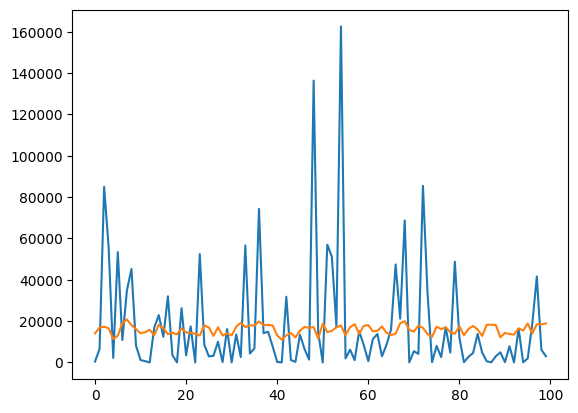

In [14]:
plt.plot(y_test.values[:100])
plt.plot(predictions[:100])
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 15093.414961633258


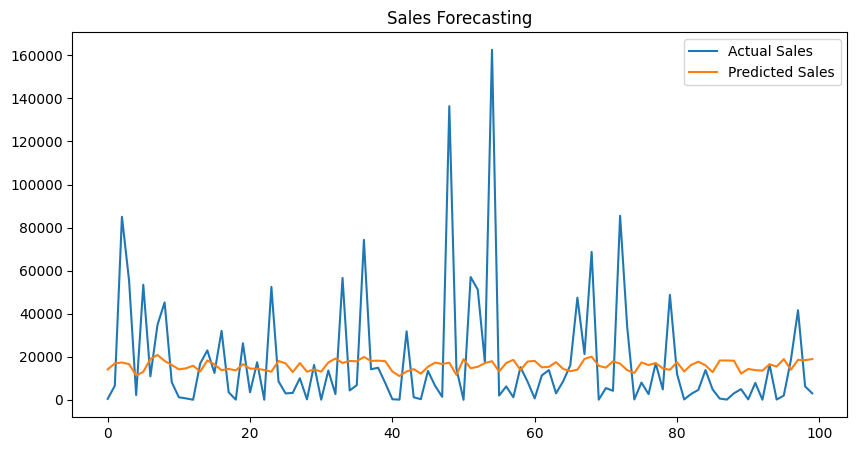

In [16]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(predictions[:100], label="Predicted Sales")
plt.legend()
plt.title("Sales Forecasting")
plt.show()